# 5. Feature extraction, from local to global

The labelled segments become a dense tree with a number attached to every point, every named vessel and the whole arch. This is the part of Arterial that turns geometry into the measurements used in the clinical studies and by the access model.

It starts from the products of notebooks 3 and 4 and runs in about a minute.

In [1]:
import numpy as np, matplotlib.pyplot as plt
from arterial_nb import *
from arterial.feature_extraction.feature_extractor import FeatureExtractor

fe = FeatureExtractor(case("features"), MODE, 2, fixture("cta.nii.gz"), derived("centerline_segments_array.npy"),
                      derived("branch_model.vtk"), derived("segments_graph_pred.pickle"))
with timed("local graph"), quiet():
    fe.build_local_graph()
g = fe.local_graph
print(f"{g.number_of_nodes()} nodes every {fe.sampling_distance_mm} mm, {g.number_of_edges()} edges")


Arterial framework for automated characterization of vascular tortuosity.
Copyright 2022-2026 Vall d'Hebron Research Institute (VHIR) and Universitat de Barcelona (UB), Barcelona, Spain.
Code licensed under the PolyForm Noncommercial License 1.0.0. Noncommercial use only.



local graph: 0.2 s
620 nodes every 2 mm, 619 edges


## The local graph

Every segment is resampled so that consecutive points sit about 2 mm apart, and the pieces are joined into one tree. Each node then gets a *hierarchy*: how many steps it is from the access point. The same tree is ordered twice, once from a femoral access at the aorta and once from a radial access at the right subclavian, because the path a catheter takes depends on where it enters.

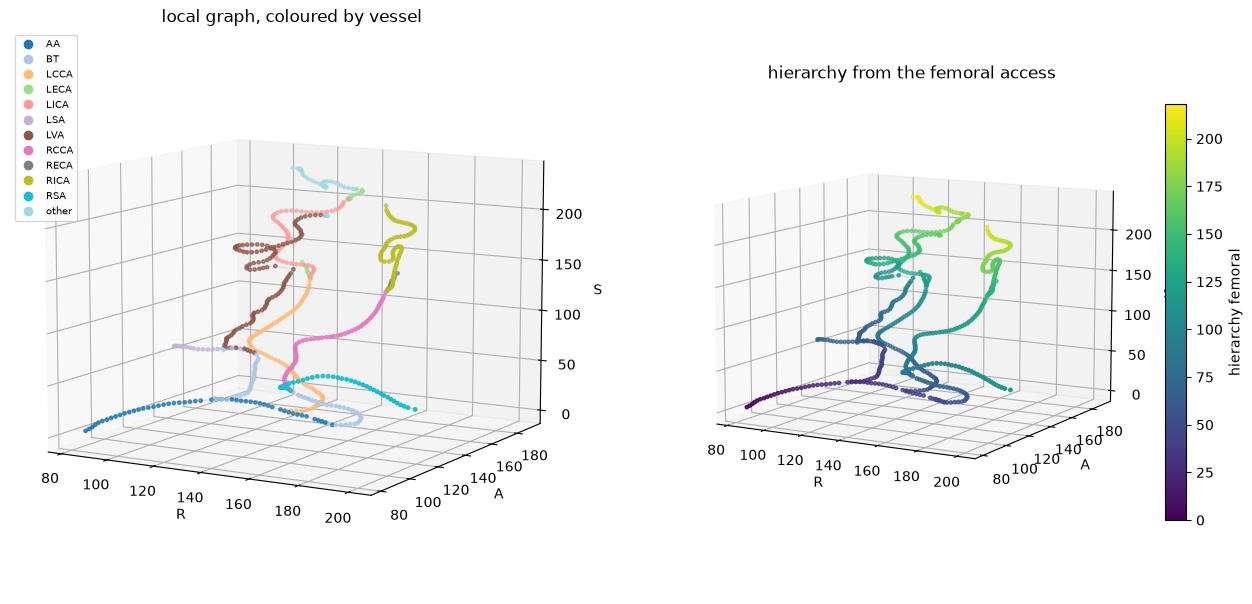

In [2]:
fig = plt.figure(figsize=(16, 9))
plot_graph(g, color_by="vessel_type_name", ax=fig.add_subplot(121, projection="3d"), title="local graph, coloured by vessel")
plot_graph(g, color_by="hierarchy femoral", ax=fig.add_subplot(122, projection="3d"), title="hierarchy from the femoral access");

## Local features

Each node gets a small set of numbers computed from its neighbourhood: radius, direction, curvature and torsion of the centerline through it, distance travelled from the access, the CT intensity there, and whether it is blanked near a bifurcation. Two versions exist, one per access.

In [3]:
with timed("local features"), quiet():
    fe.extract_local_features()
node = next(n for n in g if g.nodes[n]["vessel_type_name"] == "LCCA")
table([[k, round(float(v), 3)] for k, v in g.nodes[node]["features femoral"].items()], columns=["feature (femoral)", "value"]).T

local features: 4.1 s


,0,1,2,3,4,5,6,7,8,9,10,11,12,13
feature (femoral),pos r,pos a,pos s,radius,segment length,curvature,torsion,direction module,direction polar,direction azimuth,blanking,HU intensity,accumulated length from access,vessel_type
value,138.298,131.659,14.614,12.454,1.504,0.071,0.125,5.958,-0.24,0.541,0.0,237.0,83.704,4.0


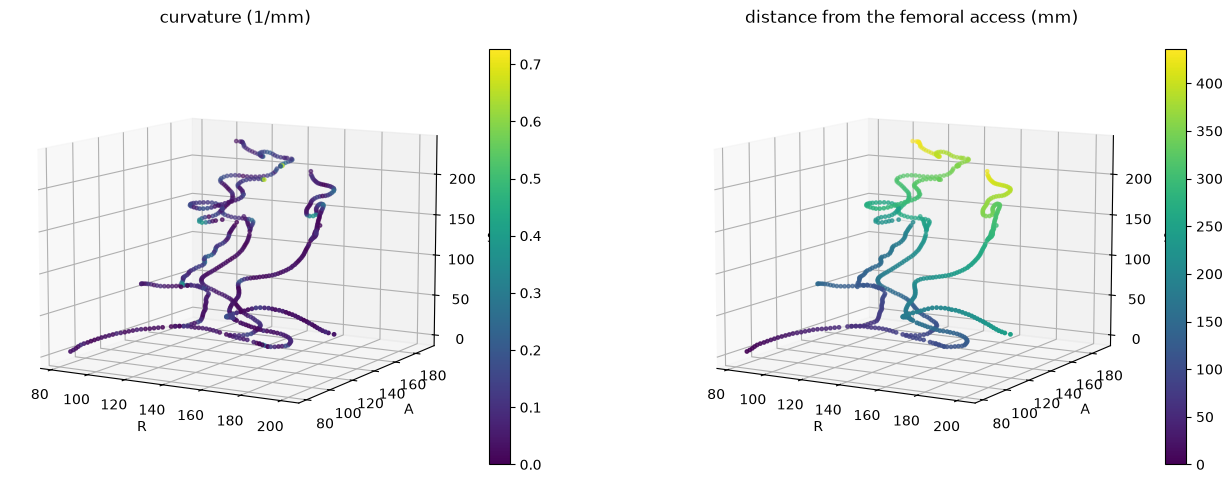

In [4]:
fig = plt.figure(figsize=(16, 9))
plot_graph(g, color_by=lambda d: d["features femoral"]["curvature"], ax=fig.add_subplot(121, projection="3d"), title="curvature (1/mm)")
plot_graph(g, color_by=lambda d: d["features femoral"]["accumulated length from access"], ax=fig.add_subplot(122, projection="3d"), title="distance from the femoral access (mm)");

## Segment features

Named vessels are cut out of the tree and measured as a whole. Length and diameters are direct; the tortuosity index compares the vessel's length to the straight distance between its ends, so a straight vessel scores 0 and a winding one approaches 1. Bending length is the largest deviation from that straight line.

segment features: 0.8 s


,vessel,length,mean_diameter,min_diameter,max_diameter,tortuosity_index,bending_length,cumulative_curvature
0,AA,105.63,25.54,22.16,27.48,0.15,24.04,1.96
1,BT,70.06,13.09,12.47,15.41,0.44,17.45,2.55
2,LCCA,156.67,7.10,5.04,25.41,0.25,20.90,3.78
3,LECA,19.75,4.15,2.11,7.39,0.02,1.05,0.50
4,LICA,113.52,3.55,1.39,7.27,0.33,25.01,5.48
5,LSA,49.21,5.54,4.69,6.52,0.10,6.99,1.45
6,LVA,229.69,2.64,1.06,6.20,0.43,28.19,13.96
7,RCCA,111.69,7.21,6.37,12.60,0.16,19.63,2.74
8,RECA,17.97,5.31,2.37,8.15,0.02,1.10,0.51
9,RICA,143.80,4.16,2.64,7.98,0.46,22.31,6.86


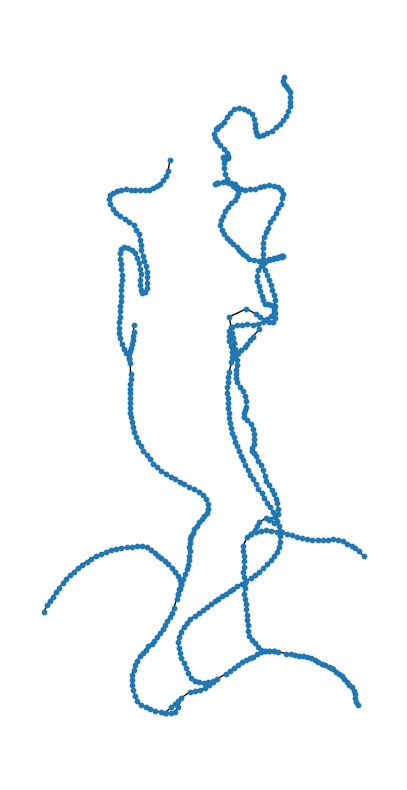

In [5]:
with timed("segment features"), quiet():
    fe.extract_segment_features()
features = fe.local_graph.graph["segment_features"]
cols = ["length", "mean_diameter", "min_diameter", "max_diameter", "tortuosity_index", "bending_length", "cumulative_curvature"]
table([[v] + [round(float(features[v][c]), 2) if c in features[v] else None for c in cols] for v in features], columns=["vessel"] + cols)

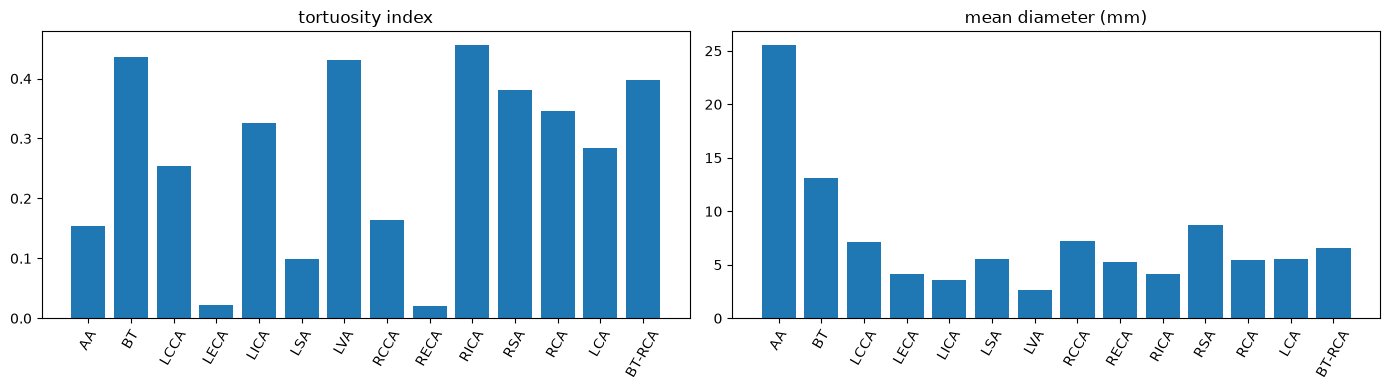

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
names = list(features)
axes[0].bar(names, [features[v]["tortuosity_index"] for v in names]); axes[0].set_title("tortuosity index"); axes[0].tick_params(axis="x", rotation=60)
axes[1].bar(names, [features[v]["mean_diameter"] for v in names]); axes[1].set_title("mean diameter (mm)"); axes[1].tick_params(axis="x", rotation=60)
plt.tight_layout()

## Global features

Three facts about the arch as a whole. The **arch type** compares the height difference between the arch apex and the origin of the brachiocephalic trunk with the diameter of the left common carotid: type 1 when the origins sit close to the apex, type 3 when they sit more than two diameters below it, which makes catheterisation harder. **Bovine arch** means the left common carotid leaves the brachiocephalic trunk instead of the arch. **ARSA** is an aberrant right subclavian artery.

In [7]:
with timed("global features"), quiet():
    fe.extract_global_features()
table([["aortic arch type", fe.local_graph.graph["aortic_arch_type"]], ["bovine arch", fe.local_graph.graph["bovine_arch"]], ["aberrant right subclavian", fe.local_graph.graph["arsa"]]], columns=["feature", "value"])

global features: 0.0 s


,feature,value
0,aortic arch type,1
1,bovine arch,0
2,aberrant right subclavian,0


## Supersegments

Finally the tree is cut into the eight pathways a catheter can follow: femoral or radial access, left or right side, anterior (carotid) or posterior (vertebral) circulation. Each pathway keeps the tree's features on its own nodes and is what the access model reads.

In [8]:
with timed("supersegments"), quiet():
    fe.extract_supersegments()
table([[" + ".join(k), v.number_of_nodes(), sum(d["features"]["is_supersegment"] for _, d in v.nodes(data=True))] for k, v in fe.supersegments.items()],
      columns=["pathway", "nodes", "nodes on the pathway"])

supersegments: 0.4 s


,pathway,nodes,nodes on the pathway
0,femoral + right + anterior,249,209
1,femoral + right + posterior,151,120
2,femoral + left + anterior,215,180
3,femoral + left + posterior,87,60
4,radial + right + anterior,186,168
5,radial + right + posterior,151,120
6,radial + left + anterior,294,258
7,radial + left + posterior,176,127


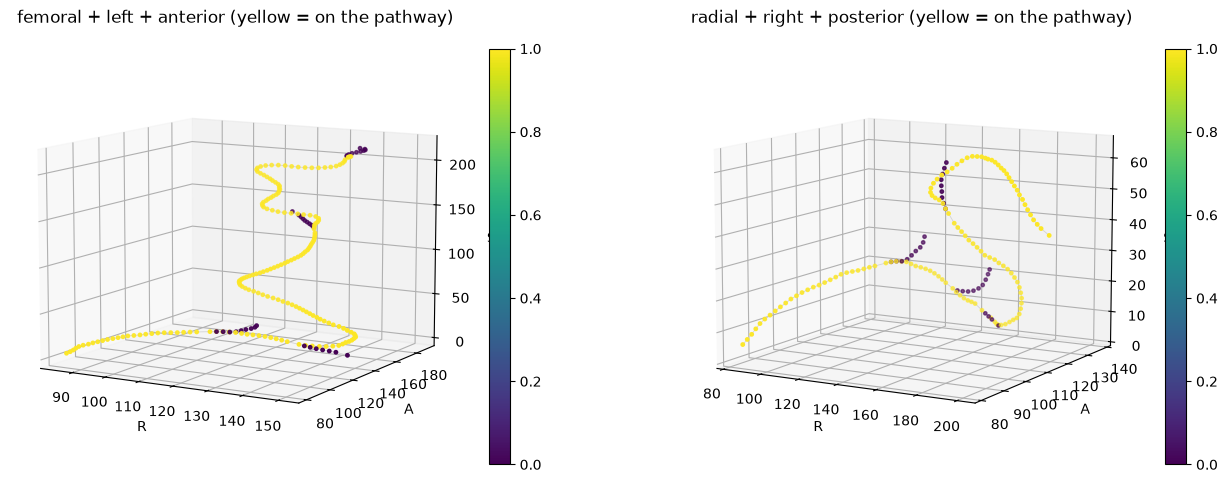

In [9]:
fig = plt.figure(figsize=(16, 9))
for idx, key in enumerate([("femoral", "left", "anterior"), ("radial", "right", "posterior")]):
    ss = fe.supersegments[key]
    plot_graph(ss, color_by=lambda d: float(d["features"]["is_supersegment"]), ax=fig.add_subplot(1, 2, idx + 1, projection="3d"), title=" + ".join(key) + " (yellow = on the pathway)")

## Notes

- All measurements use the blanked-out nodes only where nothing else is available, so a diameter is never read at a bifurcation.
- The feature definitions are frozen: the labelling and access models were trained on them, so changing a formula means retraining. Known quirks are listed in the repository notes.